In [1]:
import snapatac2 as snap
import numpy as np
import scanpy as sc

In [2]:
# Input files
fragment_file = "data/atac_pbmc_5k_nextgem_fragments.tsv.gz"
gene_annotation = "data/gencode.v39.basic.annotation.gff3.gz"

Preprocessing
============

In [3]:
# Compute QC metric and cell by 500bp-bin matrix
data = snap.pp.make_tile_matrix(
    "count_matrix.h5ad",
    fragment_file,
    gene_annotation,
    snap.genome.hg38,
    sorted_by_barcode=False,
)
data

AnnData object with n_obs × n_vars = 14227 × 6176550 backed at 'count_matrix.h5ad'
    obs: 'tsse', 'n_fragment', 'frac_dup', 'frac_mito'

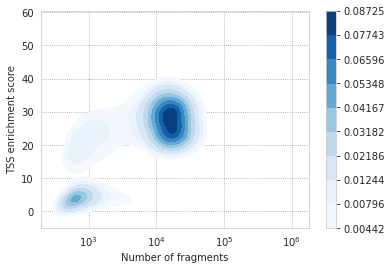

In [4]:
snap.pl.tsse(data)

In [5]:
# Select cells based on number of unique fragments and TSS enrichment scores
selected_cells = np.logical_and(data.obs["n_fragment"] >= 5000, data.obs["tsse"] >= 10)
data = data[selected_cells, :]
    
# Save filtered data to a different file
data = data.copy(filename = "count_matrix_filtered.h5ad")
data

AnnData object with n_obs × n_vars = 4566 × 6176550 backed at 'count_matrix_filtered.h5ad'
    obs: 'tsse', 'n_fragment', 'frac_dup', 'frac_mito'

In [3]:
data = snap.read("count_matrix_filtered.h5ad", backed="r")
data

AnnData object with n_obs × n_vars = 4566 × 6176550 backed at 'count_matrix_filtered.h5ad'
    obs: 'tsse', 'n_fragment', 'frac_dup', 'frac_mito'

In [4]:
gene_matrix = snap.pp.make_gene_matrix(data, gene_annotation)
gene_matrix

AnnData object with n_obs × n_vars = 4566 × 60286 backed at 'gene_matrix.h5ad'

In [5]:
gene_matrix.var_names

Index(['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M',
       'A2M-AS1', 'A2ML1', 'A2ML1-AS1',
       ...
       'ZYG11A', 'ZYG11AP1', 'ZYG11B', 'ZYX', 'ZYXP1', 'ZZEF1', 'ZZZ3',
       'hsa-mir-1253', 'hsa-mir-423', 'snoZ196'],
      dtype='object', name='ID', length=60286)

In [4]:
# Feature selection
features = snap.pp.select_features(data)

In [5]:
snap.pp.scrublet(data, features=features)

Simulating doublets...
Spectral embedding ...
Compute similarity matrix
Normalization
Perform decomposition
Calculating doublet scores...


In [9]:
data = data[data.obs["doublet_probability"] < 0.5, ]

In [8]:
# Perform dimension reduction. The result is stored in `data.obsm["X_spectral"]
snap.tl.spectral(data, features=features)

Compute similarity matrix
Normalization
Perform decomposition


In [9]:
# Perform graph-based clustering
snap.pp.knn(data)

In [10]:
# Perform UMAP
snap.tl.umap(data)

/home/kaizhang/data/software/miniconda3/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn("Tensorflow not installed; ParametricUMAP will be unavailable")


In [11]:
snap.tl.leiden(data)
snap.tl.kmeans(data, 12)

In [14]:
gene_matrix.obs = data.obs
gene_matrix.obsm = data.obsm

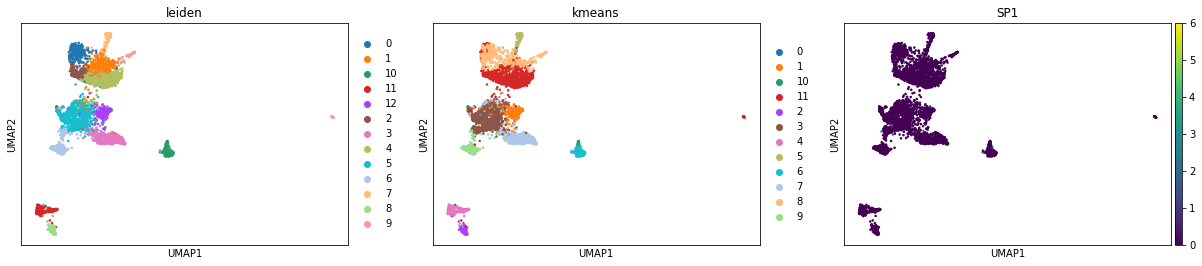

In [32]:
import scanpy as sc
sc.pl.umap(gene_matrix, color=["leiden", "kmeans", "SP1"])

In [17]:
data.obs["log_n_fragment"] = np.log10(data.obs["n_fragment"])

In [ ]:
gene_matrix.X[...].sum(axis=0)